In [185]:
import pandas as pd
import numpy as np
import missingno as msno
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split


In [68]:
df = pd.read_csv('./data/data.csv')

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

<Axes: >

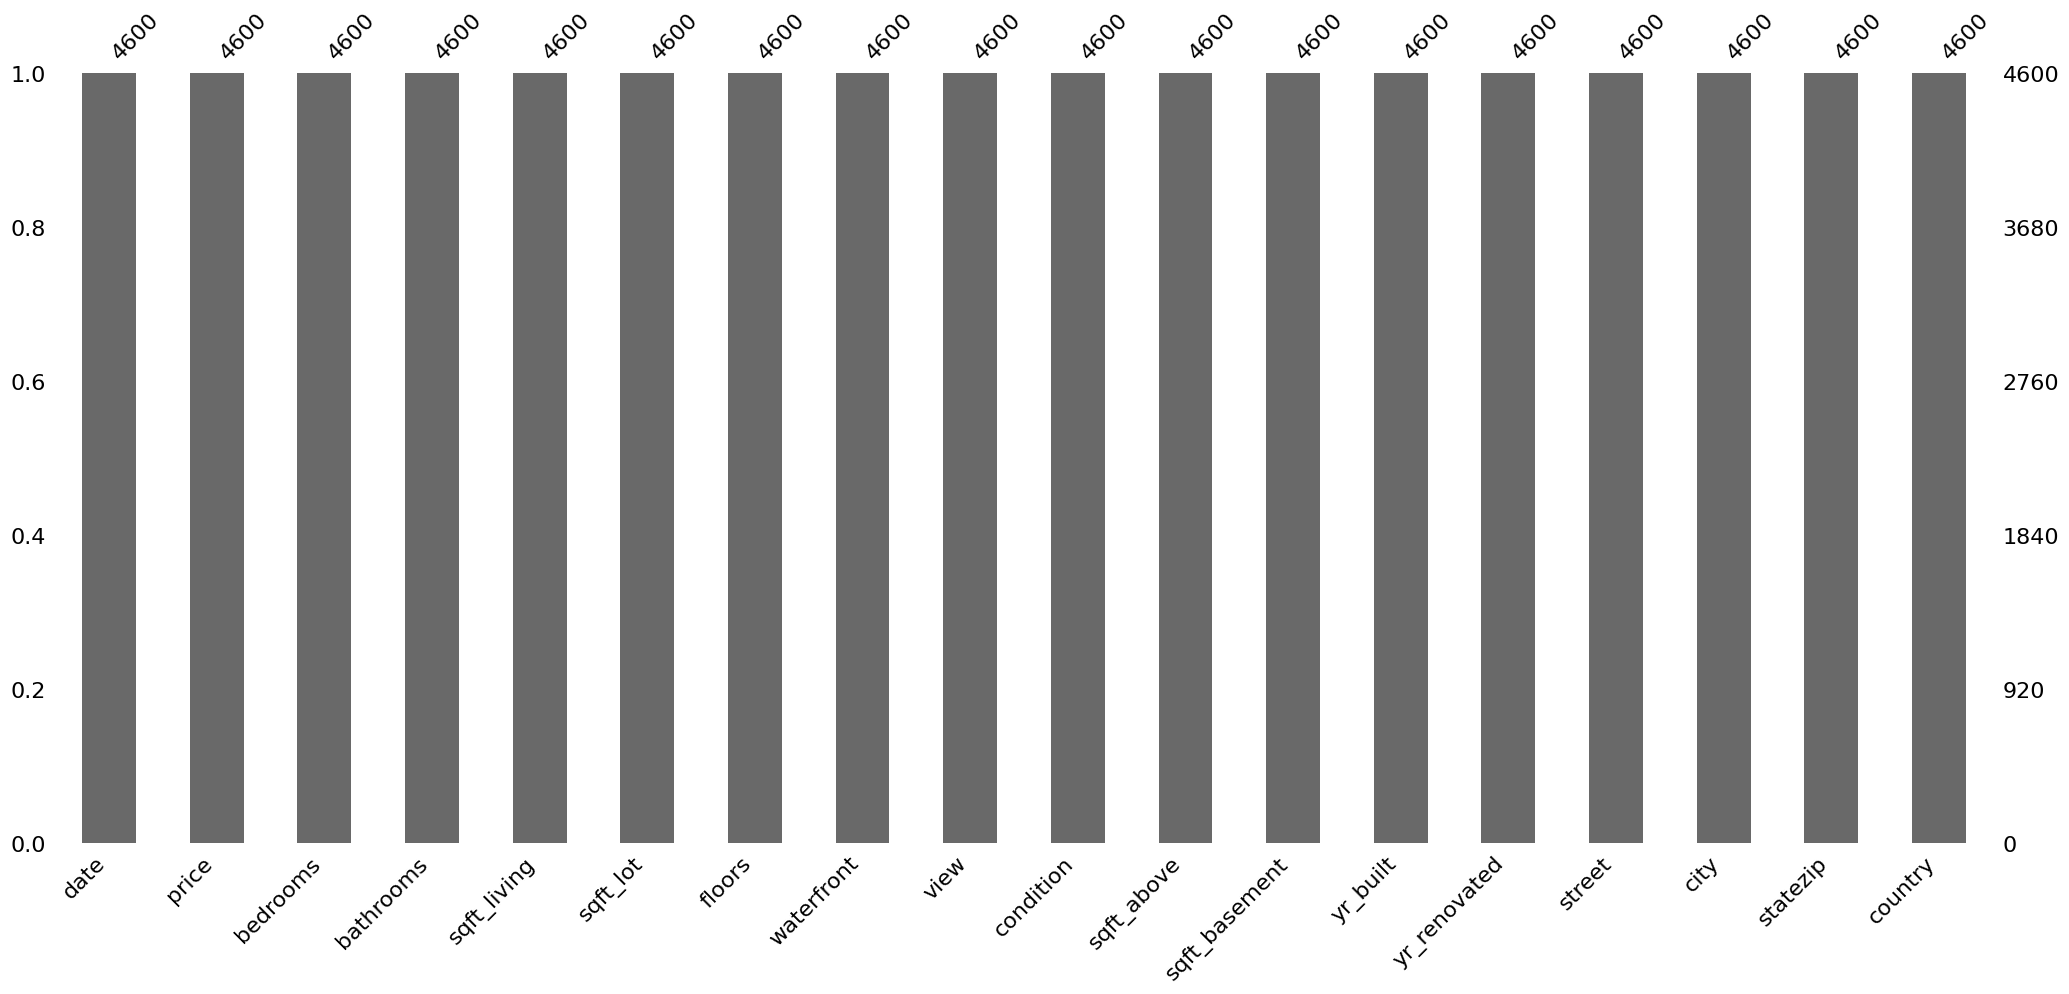

In [70]:
msno.bar(df)

<Axes: >

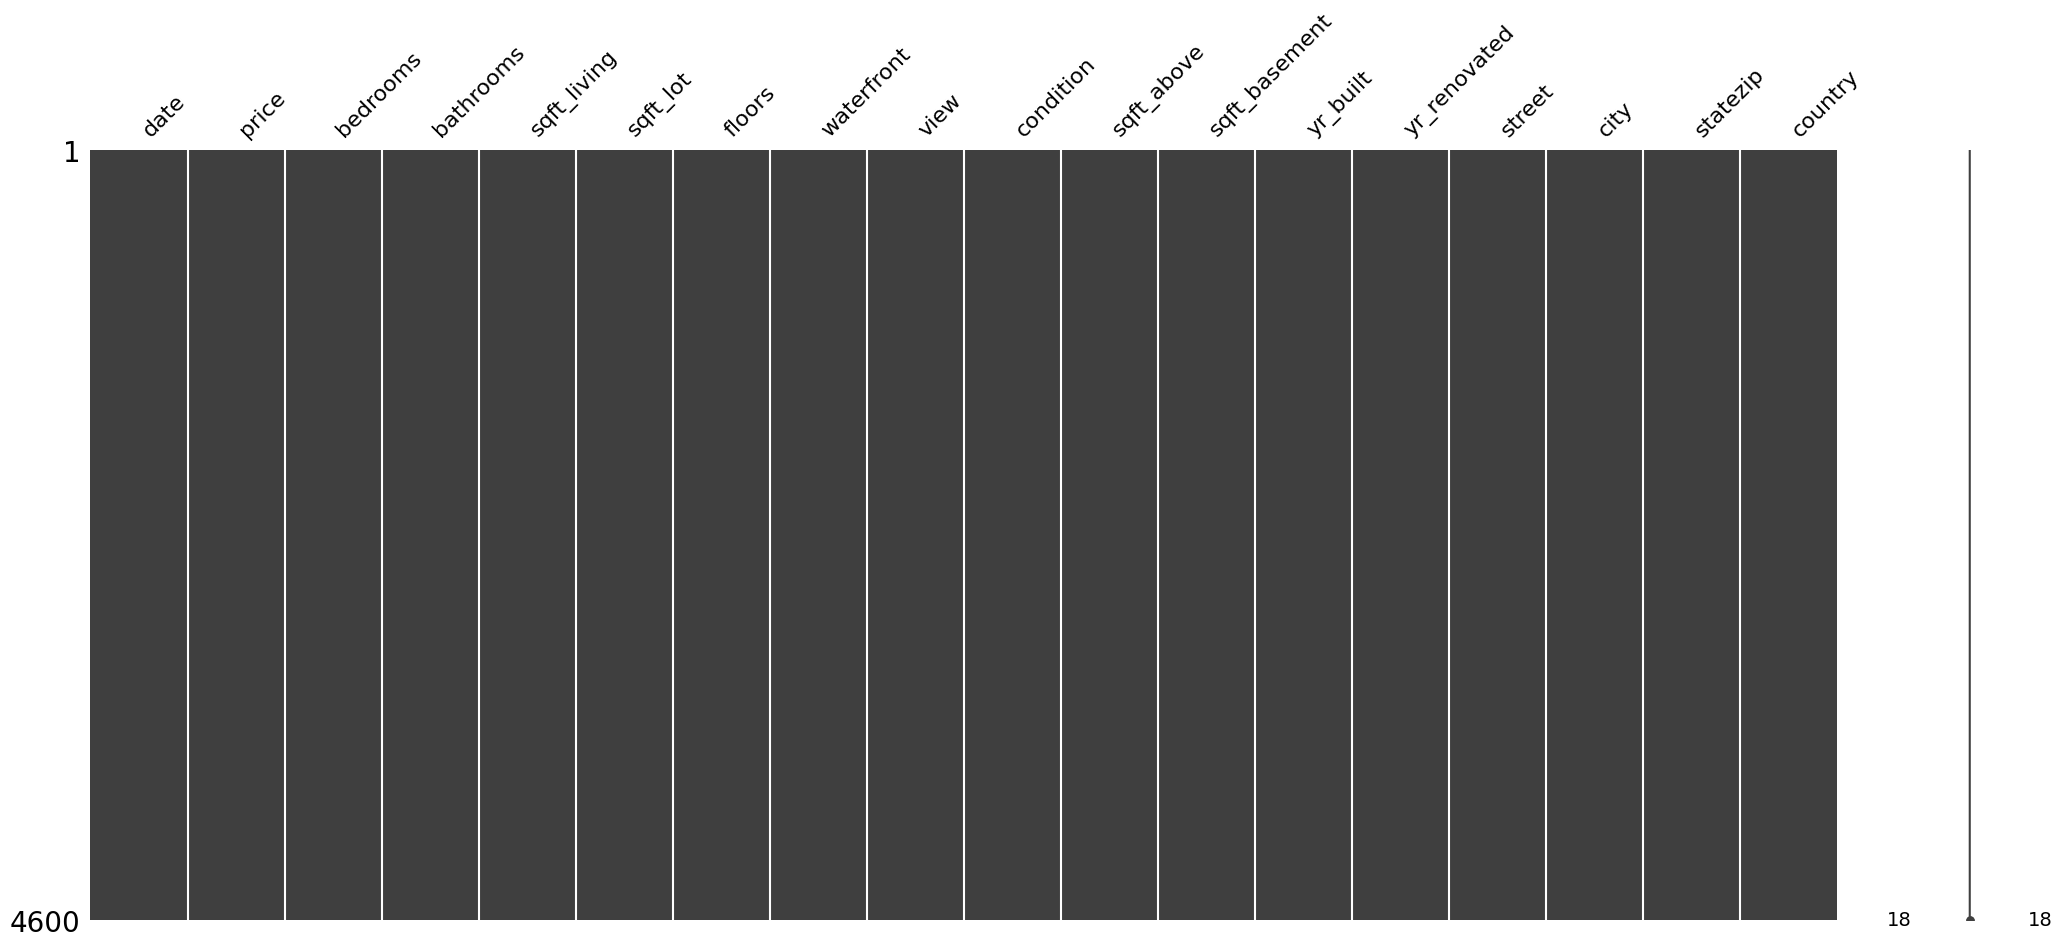

In [71]:
msno.matrix(df)

In [72]:
df['date'].head(5)

0    2014-05-02 00:00:00
1    2014-05-02 00:00:00
2    2014-05-02 00:00:00
3    2014-05-02 00:00:00
4    2014-05-02 00:00:00
Name: date, dtype: str

In [73]:
pd.to_datetime(df['date'])

0      2014-05-02
1      2014-05-02
2      2014-05-02
3      2014-05-02
4      2014-05-02
          ...    
4595   2014-07-09
4596   2014-07-09
4597   2014-07-09
4598   2014-07-10
4599   2014-07-10
Name: date, Length: 4600, dtype: datetime64[us]

In [74]:
df_clean = df.copy()

In [75]:
df_clean['date'] = pd.to_datetime(df['date'])

In [76]:
df_clean = df_clean.drop(columns=['country'])

In [77]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[us]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4600 non-null   str           
 15  city           4600 non-null   s

In [78]:
df_clean['statezip'].unique()


<StringArray>
['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052', 'WA 98115',
 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105', 'WA 98074', 'WA 98106',
 'WA 98007', 'WA 98092', 'WA 98198', 'WA 98006', 'WA 98102', 'WA 98011',
 'WA 98125', 'WA 98003', 'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117',
 'WA 98034', 'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
 'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059', 'WA 98075',
 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053', 'WA 98058', 'WA 98122',
 'WA 98103', 'WA 98112', 'WA 98005', 'WA 98118', 'WA 98177', 'WA 98004',
 'WA 98019', 'WA 98144', 'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146',
 'WA 98028', 'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
 'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032', 'WA 98178',
 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188', 'WA 98002', 'WA 98039',
 'WA 98022', 'WA 98068', 'WA 98047', 'WA 98050', 'WA 98354']
Length: 77, dtype: str

In [79]:
df_clean['city'].unique()

<StringArray>
[          'Shoreline',             'Seattle',                'Kent',
            'Bellevue',             'Redmond',        'Maple Valley',
          'North Bend',    'Lake Forest Park',           'Sammamish',
              'Auburn',          'Des Moines',             'Bothell',
         'Federal Way',            'Kirkland',            'Issaquah',
         'Woodinville',       'Normandy Park',           'Fall City',
              'Renton',           'Carnation',          'Snoqualmie',
              'Duvall',              'Burien',           'Covington',
 'Inglewood-Finn Hill',             'Kenmore',           'Newcastle',
       'Mercer Island',       'Black Diamond',          'Ravensdale',
          'Clyde Hill',              'Algona',           'Skykomish',
             'Tukwila',              'Vashon',        'Yarrow Point',
              'SeaTac',              'Medina',            'Enumclaw',
     'Snoqualmie Pass',             'Pacific',  'Beaux Arts Village',
      

In [80]:
df['city'].nunique(), df['statezip'].nunique(), df['street'].nunique()

(44, 77, 4525)

In [81]:
df_clean = df_clean.drop(columns=['statezip', 'street'])

In [82]:
onehotencoder = OneHotEncoder()
encoded_city = onehotencoder.fit_transform(X=df_clean['city'].to_frame())
df_encoded_city = pd.DataFrame(encoded_city.toarray(), columns=onehotencoder.get_feature_names_out())

In [83]:
df_clean = pd.concat([df_clean, df_encoded_city], axis=1)
df_clean = df_clean.drop(columns=['city'])

In [84]:
df_clean['date'] = df_clean['date'].dt.year

In [86]:
sold_build_diff = df_clean['date'] - df_clean['yr_built']
df_sold_build_diff = pd.DataFrame(sold_build_diff, columns=['sold build diff'])
df_clean = pd.concat([df_clean, df_sold_build_diff], axis=1)

In [87]:
ren_diff = df_clean['date'] - df_clean['yr_renovated']
ren_diff[ren_diff == df_clean['date']] = 0
df_ren_diff = pd.DataFrame(ren_diff, columns=['ren diff'])
df_clean = pd.concat([df_clean, df_ren_diff], axis=1)

In [88]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      4600 non-null   int32  
 1   price                     4600 non-null   float64
 2   bedrooms                  4600 non-null   float64
 3   bathrooms                 4600 non-null   float64
 4   sqft_living               4600 non-null   int64  
 5   sqft_lot                  4600 non-null   int64  
 6   floors                    4600 non-null   float64
 7   waterfront                4600 non-null   int64  
 8   view                      4600 non-null   int64  
 9   condition                 4600 non-null   int64  
 10  sqft_above                4600 non-null   int64  
 11  sqft_basement             4600 non-null   int64  
 12  yr_built                  4600 non-null   int64  
 13  yr_renovated              4600 non-null   int64  
 14  city_Algona        

In [90]:
df_clean = df_clean.drop(columns=['date', 'yr_built', 'yr_renovated'])

In [91]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4600 non-null   float64
 1   bedrooms                  4600 non-null   float64
 2   bathrooms                 4600 non-null   float64
 3   sqft_living               4600 non-null   int64  
 4   sqft_lot                  4600 non-null   int64  
 5   floors                    4600 non-null   float64
 6   waterfront                4600 non-null   int64  
 7   view                      4600 non-null   int64  
 8   condition                 4600 non-null   int64  
 9   sqft_above                4600 non-null   int64  
 10  sqft_basement             4600 non-null   int64  
 11  city_Algona               4600 non-null   float64
 12  city_Auburn               4600 non-null   float64
 13  city_Beaux Arts Village   4600 non-null   float64
 14  city_Bellevue      

In [97]:
df_clean['sqft_living'].head(5), df_clean['sqft_above'].head(5), df_clean['sqft_basement'].head(5)

(0    1340
 1    3650
 2    1930
 3    2000
 4    1940
 Name: sqft_living, dtype: int64,
 0    1340
 1    3370
 2    1930
 3    1000
 4    1140
 Name: sqft_above, dtype: int64,
 0       0
 1     280
 2       0
 3    1000
 4     800
 Name: sqft_basement, dtype: int64)

In [102]:
df_clean[['floors', 'price']].corr()

,floors,price
floors,1.000000,0.151461
price,0.151461,1.000000


In [103]:
df_clean.groupby('floors')['price'].mean()

floors
1.0    457278.687261
1.5    578692.700221
2.0    647985.230123
2.5    983863.390244
3.0    566157.587674
3.5    829250.000000
Name: price, dtype: float64

In [109]:
df_clean.value_counts('floors')

floors
1.0    2174
2.0    1811
1.5     444
3.0     128
2.5      41
3.5       2
Name: count, dtype: int64

In [112]:
df_clean.loc[df_clean['floors'] == 2.5, 'floors'] = 3.0
df_clean.loc[df_clean['floors'] == 3.5, 'floors'] = 3.0

In [114]:
df_clean[['price', 'floors']].corr()

,price,floors
price,1.000000,0.154886
floors,0.154886,1.000000


0       1.5
1       2.0
2       1.0
3       1.0
4       1.0
       ... 
4595    1.0
4596    2.0
4597    2.0
4598    1.0
4599    2.0
Name: floors, Length: 4600, dtype: float64

<Axes: >

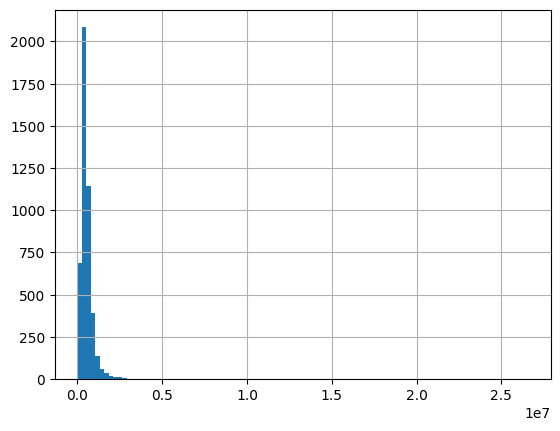

In [118]:
df_clean['price'].hist(bins=100)

In [ ]:
df_test = df_clean.copy()
df_test['price'] = np.log(df_test['price'])
df_test['price'].describe()

In [127]:
np.sum(df_clean['price'] == 0)

np.int64(49)

In [128]:
df_clean = df_clean[df_clean['price'] > 0]

In [130]:
df_test = df_clean.copy()
df_test['price'] = np.log(df_test['price'])
df_test['price'].describe()

count    4551.000000
mean       13.064963
std         0.542789
min         8.961879
25%        12.695463
50%        13.049793
75%        13.396200
max        17.096046
Name: price, dtype: float64

<Axes: >

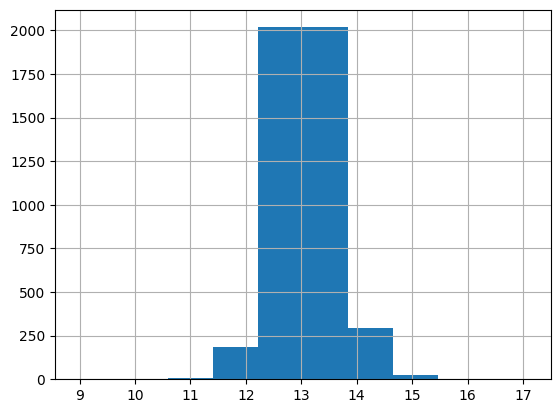

In [131]:
df_test['price'].hist()

Now let's train our baseline model and record the result.

In [ ]:

linreg = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(df_test.drop(columns=['price']), df_test['price'], random_state=42)
linreg.fit(X=X_train, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [156]:
y_pred = linreg.predict(X_test)

In [ ]:
y_pred = np.exp(y_pred)
y_real = np.exp(y_test)

rmse = np.sqrt(np.mean((y_real - y_pred)**2))


In [168]:
errors = np.abs(y_real - y_pred)
sorted(errors)[-5:]

[2026815.5155450632,
 2164085.46505392,
 3916393.2876013797,
 6069635.256010381,
 30486274.065277006]

In [159]:
rmse

np.float64(949502.0136087707)

Now i'm trying to improve our model. Lets first remove a lot of binary features for city (from OneHotEncoder) and create new feature with mean house price for this city. Then apply StandardScaler to all numeric features.

In [184]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4551 non-null   float64
 1   bedrooms                  4551 non-null   float64
 2   bathrooms                 4551 non-null   float64
 3   sqft_living               4551 non-null   float64
 4   sqft_lot                  4551 non-null   int64  
 5   floors                    4551 non-null   float64
 6   waterfront                4551 non-null   int64  
 7   view                      4551 non-null   float64
 8   condition                 4551 non-null   float64
 9   sqft_above                4551 non-null   float64
 10  sqft_basement             4551 non-null   float64
 11  city_Algona               4551 non-null   float64
 12  city_Auburn               4551 non-null   float64
 13  city_Beaux Arts Village   4551 non-null   float64
 14  city_Bellevue           

In [187]:
city_columns = [column for column in df_test.columns if 'city' in column]
df_test = df_test.drop(columns=city_columns)

In [193]:
statezip_mean_price = df.groupby('statezip')['price'].mean()
statezip_mean_price = np.log(statezip_mean_price)

In [195]:
df_test['statezip_mean_price'] = df['statezip'].map(statezip_mean_price)

In [196]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                4551 non-null   float64
 1   bedrooms             4551 non-null   float64
 2   bathrooms            4551 non-null   float64
 3   sqft_living          4551 non-null   float64
 4   sqft_lot             4551 non-null   int64  
 5   floors               4551 non-null   float64
 6   waterfront           4551 non-null   int64  
 7   view                 4551 non-null   float64
 8   condition            4551 non-null   float64
 9   sqft_above           4551 non-null   float64
 10  sqft_basement        4551 non-null   float64
 11  sold build diff      4551 non-null   int64  
 12  ren diff             4551 non-null   int64  
 13  statezip_mean_price  4551 non-null   float64
dtypes: float64(10), int64(4)
memory usage: 533.3 KB


In [198]:
X_train, X_test, y_train, y_test = train_test_split(df_test.drop(columns=['price']), df_test['price'], random_state=42)
linreg.fit(X=X_train, y=y_train)

y_pred = linreg.predict(X_test)

y_pred = np.exp(y_pred)
y_real = np.exp(y_test)
rmse = np.sqrt(np.mean((y_real - y_pred)**2))

In [199]:
rmse

np.float64(566690.1002013951)